In [112]:
import os 
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time 
import torchvision.models as models 
from matplotlib import pyplot as plt 
import optuna

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## LOAD DATA 

In [26]:
# Resizing the image for CNN 
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2) ,
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224,  0.225])
])

In [28]:
dataset_path = "./dataset"
dataset = datasets.ImageFolder(root = dataset_path, transform = image_transforms )
len(dataset)

2300

In [120]:
class_names = dataset.classes
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [32]:
num_classes = len(dataset.classes)
num_classes

6

In [34]:
train_size = int(0.75*len(dataset))
val_size = len(dataset) - train_size 

train_size, val_size 

(1725, 575)

In [38]:
 from torch.utils.data import random_split 

train_dataset, val_dataset =  random_split(dataset, [train_size, val_size])

In [40]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = True)

In [42]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [44]:
labels[0]

tensor(0)

In [46]:
images[0].shape

torch.Size([3, 224, 224])

In [48]:
images[0].permute(1, 2, 0).shape

torch.Size([224, 224, 3])

In [50]:
# rearranging the index 
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


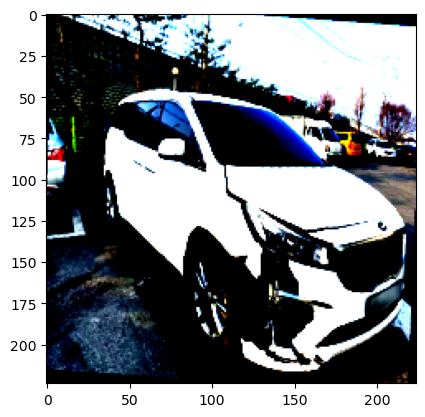

In [52]:
plt.imshow(images[0].permute(1,2,0))
plt.show()

## Model 1: CNN 

In [57]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), #(16, 112, 112),
            nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, stride =1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), #(32, 56, 56)
            nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride =1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), #(64, 28, 28)
            nn.Flatten(), 
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.network(x)
        return x 

In [59]:
# Instantiate the model, loss function, and optimizer
model = CarClassifierCNN(num_classes = num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [74]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
                
            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")
            
    end = time.time()
    print(f"Execution time: {end - start} seconds")     
    
    return all_labels, all_predictions

In [76]:
train_model(model, criterion, optimizer, epochs = 1)

Batch: 10, Epoch: 1, Loss: 1.80
Batch: 20, Epoch: 1, Loss: 1.78
Batch: 30, Epoch: 1, Loss: 1.74
Batch: 40, Epoch: 1, Loss: 1.60
Batch: 50, Epoch: 1, Loss: 1.44
Epoch [1/1], Avg Loss: 1.8696
*** Validation Accuracy: 39.83% ***
Execution time: 100.57983922958374 seconds


([4,
  2,
  3,
  0,
  5,
  4,
  4,
  2,
  1,
  4,
  0,
  5,
  3,
  2,
  2,
  1,
  2,
  3,
  5,
  3,
  0,
  3,
  5,
  1,
  0,
  4,
  1,
  2,
  2,
  0,
  0,
  5,
  4,
  4,
  0,
  0,
  4,
  4,
  1,
  4,
  0,
  1,
  3,
  1,
  1,
  1,
  0,
  3,
  1,
  3,
  4,
  4,
  0,
  4,
  3,
  0,
  1,
  1,
  0,
  4,
  2,
  3,
  2,
  4,
  0,
  5,
  1,
  4,
  1,
  3,
  4,
  5,
  2,
  4,
  2,
  3,
  1,
  1,
  5,
  0,
  3,
  4,
  2,
  2,
  1,
  3,
  2,
  1,
  0,
  1,
  4,
  1,
  3,
  3,
  2,
  0,
  2,
  3,
  5,
  5,
  2,
  0,
  3,
  5,
  1,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  3,
  0,
  0,
  2,
  4,
  2,
  2,
  4,
  5,
  2,
  1,
  1,
  2,
  1,
  2,
  5,
  0,
  1,
  1,
  3,
  0,
  1,
  4,
  0,
  3,
  3,
  1,
  4,
  4,
  1,
  5,
  3,
  0,
  5,
  1,
  2,
  4,
  1,
  2,
  2,
  1,
  2,
  1,
  2,
  3,
  3,
  3,
  4,
  4,
  5,
  2,
  1,
  3,
  2,
  0,
  2,
  0,
  5,
  2,
  0,
  2,
  0,
  5,
  3,
  1,
  5,
  2,
  1,
  2,
  1,
  0,
  2,
  0,
  4,
  4,
  0,
  3,
  2,
  5,
  4,
  0,
  5,
  1,
  0,
  3,
  5,


In [78]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs = 5)

Batch: 10, Epoch: 1, Loss: 1.46
Batch: 20, Epoch: 1, Loss: 1.73
Batch: 30, Epoch: 1, Loss: 1.45
Batch: 40, Epoch: 1, Loss: 1.18
Batch: 50, Epoch: 1, Loss: 1.29
Epoch [1/5], Avg Loss: 1.3437
*** Validation Accuracy: 45.04% ***
Batch: 10, Epoch: 2, Loss: 1.00
Batch: 20, Epoch: 2, Loss: 1.13
Batch: 30, Epoch: 2, Loss: 1.17
Batch: 40, Epoch: 2, Loss: 1.11
Batch: 50, Epoch: 2, Loss: 0.98
Epoch [2/5], Avg Loss: 1.1239
*** Validation Accuracy: 53.04% ***
Batch: 10, Epoch: 3, Loss: 0.83
Batch: 20, Epoch: 3, Loss: 1.05
Batch: 30, Epoch: 3, Loss: 0.70
Batch: 40, Epoch: 3, Loss: 1.08
Batch: 50, Epoch: 3, Loss: 1.23
Epoch [3/5], Avg Loss: 0.9913
*** Validation Accuracy: 50.96% ***
Batch: 10, Epoch: 4, Loss: 0.88
Batch: 20, Epoch: 4, Loss: 1.28
Batch: 30, Epoch: 4, Loss: 0.86
Batch: 40, Epoch: 4, Loss: 0.92
Batch: 50, Epoch: 4, Loss: 0.82
Epoch [4/5], Avg Loss: 0.9280
*** Validation Accuracy: 51.65% ***
Batch: 10, Epoch: 5, Loss: 1.03
Batch: 20, Epoch: 5, Loss: 0.80
Batch: 30, Epoch: 5, Loss: 0.70


## Model 2 : CNN with Regularization 

In [81]:
class CarClassifierCNNwithRegularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, stride = 1, padding = 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), #(16, 112, 112),
            nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, stride =1, padding = 1),
             nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), #(32, 56, 56)
            nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride =1, padding = 1),
             nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), #(64, 28, 28)
            nn.Flatten(), 
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.network(x)
        return x 

In [83]:
model = CarClassifierCNN(num_classes = num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay = 1e-4)

train_model(model, criterion, optimizer, epochs = 10)

Batch: 10, Epoch: 1, Loss: 1.79
Batch: 20, Epoch: 1, Loss: 1.79
Batch: 30, Epoch: 1, Loss: 1.78
Batch: 40, Epoch: 1, Loss: 1.75
Batch: 50, Epoch: 1, Loss: 1.57
Epoch [1/10], Avg Loss: 1.8249
*** Validation Accuracy: 32.00% ***
Batch: 10, Epoch: 2, Loss: 1.57
Batch: 20, Epoch: 2, Loss: 1.17
Batch: 30, Epoch: 2, Loss: 1.47
Batch: 40, Epoch: 2, Loss: 1.39
Batch: 50, Epoch: 2, Loss: 1.65
Epoch [2/10], Avg Loss: 1.4631
*** Validation Accuracy: 40.52% ***
Batch: 10, Epoch: 3, Loss: 1.13
Batch: 20, Epoch: 3, Loss: 1.10
Batch: 30, Epoch: 3, Loss: 1.48
Batch: 40, Epoch: 3, Loss: 1.21
Batch: 50, Epoch: 3, Loss: 1.43
Epoch [3/10], Avg Loss: 1.3044
*** Validation Accuracy: 46.78% ***
Batch: 10, Epoch: 4, Loss: 0.92
Batch: 20, Epoch: 4, Loss: 1.72
Batch: 30, Epoch: 4, Loss: 1.06
Batch: 40, Epoch: 4, Loss: 1.41
Batch: 50, Epoch: 4, Loss: 1.12
Epoch [4/10], Avg Loss: 1.1860
*** Validation Accuracy: 47.65% ***
Batch: 10, Epoch: 5, Loss: 1.07
Batch: 20, Epoch: 5, Loss: 1.32
Batch: 30, Epoch: 5, Loss: 1

([4,
  3,
  1,
  3,
  5,
  3,
  0,
  3,
  1,
  1,
  3,
  4,
  1,
  1,
  1,
  3,
  3,
  3,
  5,
  2,
  3,
  1,
  0,
  1,
  4,
  4,
  1,
  3,
  4,
  0,
  1,
  1,
  1,
  4,
  0,
  2,
  2,
  5,
  0,
  5,
  0,
  4,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  5,
  0,
  5,
  3,
  4,
  1,
  0,
  3,
  4,
  5,
  3,
  5,
  5,
  1,
  0,
  4,
  2,
  4,
  2,
  3,
  1,
  4,
  1,
  3,
  5,
  0,
  2,
  2,
  1,
  0,
  2,
  2,
  4,
  0,
  3,
  0,
  0,
  5,
  3,
  2,
  0,
  2,
  4,
  0,
  1,
  0,
  2,
  0,
  4,
  1,
  4,
  0,
  2,
  2,
  0,
  2,
  2,
  5,
  2,
  2,
  0,
  0,
  5,
  0,
  4,
  0,
  1,
  2,
  5,
  1,
  1,
  1,
  4,
  0,
  0,
  1,
  0,
  0,
  1,
  5,
  4,
  4,
  4,
  2,
  4,
  3,
  1,
  2,
  4,
  2,
  1,
  2,
  0,
  0,
  2,
  1,
  3,
  2,
  2,
  2,
  2,
  0,
  0,
  3,
  5,
  1,
  3,
  5,
  2,
  1,
  2,
  5,
  0,
  2,
  2,
  5,
  5,
  3,
  1,
  1,
  0,
  4,
  0,
  2,
  1,
  2,
  0,
  5,
  0,
  2,
  0,
  4,
  4,
  0,
  1,
  1,
  3,
  1,
  4,
  2,
  0,
  3,
  5,
  3,
  5,
  5,
  0,
  1,
  2,
  0,
  5,


## Model 3 : Transfer Learning with EfficientNet 

In [101]:
class CarClassifierCNNwithEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')
        
        for param in self.model.parameters():
            param.requires_grad = False
        
        in_features = self.model.classifier[1].in_features
        
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )
        
    def forward(self, x):
        x = self.model(x)
        return x              

In [103]:
model = CarClassifierCNNwithEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.67
Batch: 20, Epoch: 1, Loss: 1.58
Batch: 30, Epoch: 1, Loss: 1.65
Batch: 40, Epoch: 1, Loss: 1.24
Batch: 50, Epoch: 1, Loss: 1.21
Epoch [1/10], Avg Loss: 1.4933
*** Validation Accuracy: 54.78% ***
Batch: 10, Epoch: 2, Loss: 1.06
Batch: 20, Epoch: 2, Loss: 1.17
Batch: 30, Epoch: 2, Loss: 1.14
Batch: 40, Epoch: 2, Loss: 1.02
Batch: 50, Epoch: 2, Loss: 1.10
Epoch [2/10], Avg Loss: 1.1348
*** Validation Accuracy: 61.91% ***
Batch: 10, Epoch: 3, Loss: 1.03
Batch: 20, Epoch: 3, Loss: 0.89
Batch: 30, Epoch: 3, Loss: 0.90
Batch: 40, Epoch: 3, Loss: 1.00
Batch: 50, Epoch: 3, Loss: 1.11
Epoch [3/10], Avg Loss: 1.0298
*** Validation Accuracy: 61.04% ***
Batch: 10, Epoch: 4, Loss: 0.96
Batch: 20, Epoch: 4, Loss: 1.11
Batch: 30, Epoch: 4, Loss: 0.92
Batch: 40, Epoch: 4, Loss: 1.04
Batch: 50, Epoch: 4, Loss: 0.87
Epoch [4/10], Avg Loss: 0.9580
*** Validation Accuracy: 64.52% ***
Batch: 10, Epoch: 5, Loss: 0.89
Batch: 20, Epoch: 5, Loss: 0.98
Batch: 30, Epoch: 5, Loss: 0

## Model 4 - Transfer Learning with Resnet 

In [108]:
# Load the pre-trained ResNet model
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True            
            
        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [110]:
model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\arsh1/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:14<00:00, 7.21MB/s]


Batch: 10, Epoch: 1, Loss: 1.08
Batch: 20, Epoch: 1, Loss: 0.90
Batch: 30, Epoch: 1, Loss: 0.65
Batch: 40, Epoch: 1, Loss: 0.98
Batch: 50, Epoch: 1, Loss: 0.55
Epoch [1/10], Avg Loss: 0.8709
*** Validation Accuracy: 75.30% ***
Batch: 10, Epoch: 2, Loss: 0.72
Batch: 20, Epoch: 2, Loss: 0.37
Batch: 30, Epoch: 2, Loss: 0.35
Batch: 40, Epoch: 2, Loss: 0.37
Batch: 50, Epoch: 2, Loss: 0.52
Epoch [2/10], Avg Loss: 0.4736
*** Validation Accuracy: 79.13% ***
Batch: 10, Epoch: 3, Loss: 0.31
Batch: 20, Epoch: 3, Loss: 0.40
Batch: 30, Epoch: 3, Loss: 0.27
Batch: 40, Epoch: 3, Loss: 0.17
Batch: 50, Epoch: 3, Loss: 0.20
Epoch [3/10], Avg Loss: 0.2953
*** Validation Accuracy: 75.30% ***
Batch: 10, Epoch: 4, Loss: 0.37
Batch: 20, Epoch: 4, Loss: 0.26
Batch: 30, Epoch: 4, Loss: 0.16
Batch: 40, Epoch: 4, Loss: 0.17
Batch: 50, Epoch: 4, Loss: 0.39
Epoch [4/10], Avg Loss: 0.2775
*** Validation Accuracy: 76.70% ***
Batch: 10, Epoch: 5, Loss: 0.21
Batch: 20, Epoch: 5, Loss: 0.25
Batch: 30, Epoch: 5, Loss: 0

## After using Optuna 

In [115]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.005)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.02
Batch: 20, Epoch: 1, Loss: 0.93
Batch: 30, Epoch: 1, Loss: 0.76
Batch: 40, Epoch: 1, Loss: 0.40
Batch: 50, Epoch: 1, Loss: 0.93
Epoch [1/10], Avg Loss: 0.8788
*** Validation Accuracy: 71.83% ***
Batch: 10, Epoch: 2, Loss: 0.39
Batch: 20, Epoch: 2, Loss: 0.62
Batch: 30, Epoch: 2, Loss: 0.42
Batch: 40, Epoch: 2, Loss: 0.67
Batch: 50, Epoch: 2, Loss: 0.61
Epoch [2/10], Avg Loss: 0.5152
*** Validation Accuracy: 77.04% ***
Batch: 10, Epoch: 3, Loss: 0.41
Batch: 20, Epoch: 3, Loss: 0.41
Batch: 30, Epoch: 3, Loss: 0.33
Batch: 40, Epoch: 3, Loss: 0.37
Batch: 50, Epoch: 3, Loss: 0.59
Epoch [3/10], Avg Loss: 0.3798
*** Validation Accuracy: 54.26% ***
Batch: 10, Epoch: 4, Loss: 0.34
Batch: 20, Epoch: 4, Loss: 0.26
Batch: 30, Epoch: 4, Loss: 0.18
Batch: 40, Epoch: 4, Loss: 0.36
Batch: 50, Epoch: 4, Loss: 0.27
Epoch [4/10], Avg Loss: 0.3516
*** Validation Accuracy: 76.35% ***
Batch: 10, Epoch: 5, Loss: 0.13
Batch: 20, Epoch: 5, Loss: 0.16
Batch: 30, Epoch: 5, Loss: 0

## Model Evaluation using confusion matrix and classification report 

In [118]:
from sklearn.metrics import classification_report 

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.77      0.81      0.79       124
           1       0.69      0.77      0.72       108
           2       0.95      0.82      0.88       120
           3       0.87      0.83      0.85        71
           4       0.72      0.77      0.75        74
           5       0.85      0.81      0.83        78

    accuracy                           0.80       575
   macro avg       0.81      0.80      0.80       575
weighted avg       0.81      0.80      0.80       575



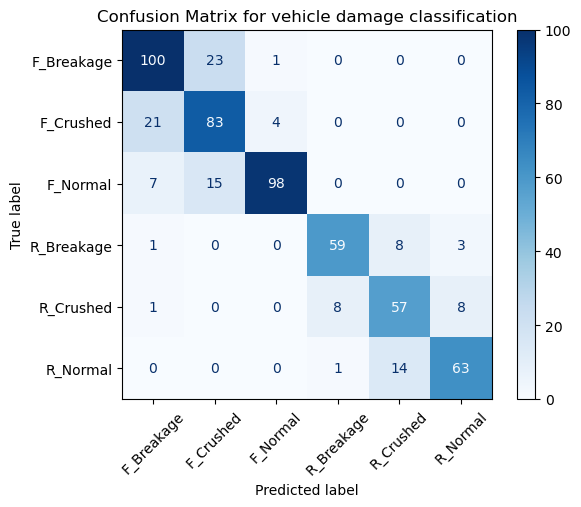

In [122]:
import numpy as np 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels = np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = class_names)
disp.plot(cmap = plt.cm.Blues, xticks_rotation = 45)
plt.title("Confusion Matrix for vehicle damage classification")
plt.show()

In [126]:
torch.save(model.state_dict(), 'saved_model.pth')